# Day 40
- Multiple Linear Regression (MLR)

In [3]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

from DailyDSML.Day39.index import X_train, X_test, linear_reg, Y_pred

data_df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv")

data_df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


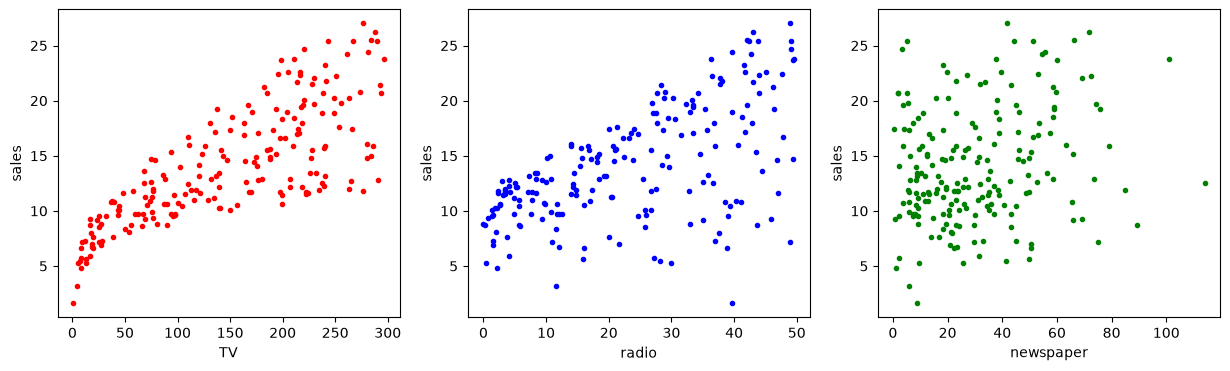

In [4]:
fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3)

ax= fig.add_subplot(gs[0])
ax.scatter(data_df["TV"],data_df["sales"],color="red",marker=".")
ax.set_xlabel("TV")
ax.set_ylabel("sales")


ax= fig.add_subplot(gs[1])
ax.scatter(data_df["radio"],data_df["sales"],color="blue",marker=".")
ax.set_xlabel("radio")
ax.set_ylabel("sales")

ax= fig.add_subplot(gs[2])
ax.scatter(data_df["newspaper"],data_df["sales"],color="green",marker=".")
ax.set_xlabel("newspaper")
ax.set_ylabel("sales")


plt.show()

In [5]:
from IPython.display import display,Math

x = data_df[["TV", "radio","newspaper"]]
y = data_df[["sales"]]


In [6]:
X = np.c_[np.ones((200,1)),x] # set bias term to 1 for each 200 samples
X

array([[  1. , 230.1,  37.8,  69.2],
       [  1. ,  44.5,  39.3,  45.1],
       [  1. ,  17.2,  45.9,  69.3],
       [  1. , 151.5,  41.3,  58.5],
       [  1. , 180.8,  10.8,  58.4],
       [  1. ,   8.7,  48.9,  75. ],
       [  1. ,  57.5,  32.8,  23.5],
       [  1. , 120.2,  19.6,  11.6],
       [  1. ,   8.6,   2.1,   1. ],
       [  1. , 199.8,   2.6,  21.2],
       [  1. ,  66.1,   5.8,  24.2],
       [  1. , 214.7,  24. ,   4. ],
       [  1. ,  23.8,  35.1,  65.9],
       [  1. ,  97.5,   7.6,   7.2],
       [  1. , 204.1,  32.9,  46. ],
       [  1. , 195.4,  47.7,  52.9],
       [  1. ,  67.8,  36.6, 114. ],
       [  1. , 281.4,  39.6,  55.8],
       [  1. ,  69.2,  20.5,  18.3],
       [  1. , 147.3,  23.9,  19.1],
       [  1. , 218.4,  27.7,  53.4],
       [  1. , 237.4,   5.1,  23.5],
       [  1. ,  13.2,  15.9,  49.6],
       [  1. , 228.3,  16.9,  26.2],
       [  1. ,  62.3,  12.6,  18.3],
       [  1. , 262.9,   3.5,  19.5],
       [  1. , 142.9,  29.3,  12.6],
 

In [7]:
X_transpose = np.transpose(X)

In [8]:
X_transpose

array([[  1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
      

In [9]:
beta_value = np.linalg.inv(X_transpose.dot(X)).dot(X_transpose).dot(y)

In [10]:
beta_value

array([[ 2.93888937e+00],
       [ 4.57646455e-02],
       [ 1.88530017e-01],
       [-1.03749304e-03]])

In [11]:
display(Math(r"\mathbf{TV, \ Radio, \ and \ Newspaper}"))
display(Math(rf"y = {beta_value[0,0]:.2f} {beta_value[1,0]:+.2f}x_1 {beta_value[2,0]:+.2f}x_2 {beta_value[3,0]:+.2f}x_3"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score



In [13]:
X = data_df[["TV", "radio","newspaper"]]
Y = data_df[["sales"]].to_numpy()



In [14]:
scaler = StandardScaler()
scaler_x = scaler.fit_transform(X)


In [15]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)


In [16]:
linear_reg = LinearRegression()
linear_reg.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[0.04,0.19,0. ]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','radio','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[2.98]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [17]:
linear_reg.coef_

array([[0.04472952, 0.18919505, 0.00276111]])

In [18]:
linear_reg.intercept_

array([2.97906734])

In [19]:
Y_pred = linear_reg.predict(X_test)
Y_pred

array([[16.4080242 ],
       [20.88988209],
       [21.55384318],
       [10.60850256],
       [22.11237326],
       [13.10559172],
       [21.05719192],
       [ 7.46101034],
       [13.60634581],
       [15.15506967],
       [ 9.04831992],
       [ 6.65328312],
       [14.34554487],
       [ 8.90349333],
       [ 9.68959028],
       [12.16494386],
       [ 8.73628397],
       [16.26507258],
       [10.27759582],
       [18.83109103],
       [19.56036653],
       [13.25103464],
       [12.33620695],
       [21.30695132],
       [ 7.82740305],
       [ 5.80957448],
       [20.75753231],
       [11.98138077],
       [ 9.18349576],
       [ 8.5066991 ],
       [12.46646769],
       [10.00337695],
       [21.3876709 ],
       [12.24966368],
       [18.26661538],
       [20.13766267],
       [14.05514005],
       [20.85411186],
       [11.0174441 ],
       [ 4.56899622]])

In [20]:
SSE = np.sum(np.power((Y_test - Y_pred),2))


In [21]:
r2_score(Y_test,Y_pred)


0.899438024100912